<a href="https://colab.research.google.com/github/taraswoj/pybibx/blob/main/pyBibX_03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
############################################################################

# Created by: Prof. Valdecy Pereira, D.Sc.
# UFF - Universidade Federal Fluminense (Brazil)
# email:  valdecy.pereira@gmail.com
# pyBibX - A Bibliometric and Scientometric Library
# Example - Scopus + WOS

# Citation:
# PEREIRA, V.; BASILIO, M.P.; SANTOS, C.H.T. (2025). PyBibX: A Python Library for Bibliometric and
# Scientometric Analysis Powered with Artificial Intelligence Tools. Data Technologies and Applications.
# Vol. 59, Iss. 2, pp. 302-337. doi: https://doi.org/10.1108/DTA-08-2023-0461

############################################################################

In [27]:
!pip install pybibx
!pip install tabulate

In [28]:
# Dowload .bib files
!wget https://raw.githubusercontent.com/taraswoj/pybibx/refs/heads/main/assets/analiza/scopus_analiza.bib
!wget https://raw.githubusercontent.com/taraswoj/pybibx/refs/heads/main/assets/analiza/wos_analiza.bib

--2026-01-23 17:23:56--  https://raw.githubusercontent.com/taraswoj/pybibx/refs/heads/main/assets/analiza/scopus_analiza.bib
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3759339 (3.6M) [text/plain]
Saving to: ‘scopus_analiza.bib.1’

scopus_analiza.bib. 100%[===================>]   3.58M  --.-KB/s    in 0.09s   

2026-01-23 17:23:57 (38.2 MB/s) - ‘scopus_analiza.bib.1’ saved [3759339/3759339]

--2026-01-23 17:23:57--  https://raw.githubusercontent.com/taraswoj/pybibx/refs/heads/main/assets/analiza/wos_analiza.bib
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awa

In [29]:
# Required Libraries
import numpy as np
import pandas as pd
import textwrap

from google.colab import data_table
from tabulate import tabulate
from prettytable import PrettyTable
from pybibx.base import pbx_probe

# Load Dataset
---
In this section, we will load and inspect the dataset.

In [30]:
# Load .bib
# Arguments: file_bib = 'filename.bib'; db = 'scopus', 'wos', 'pubmed'; del_duplicated = True, False
file_name = 'scopus_analiza.bib'
database  = 'scopus'
bibfile   = pbx_probe(file_bib = file_name, db = database, del_duplicated = False)

A Total of 1389 Documents were Found

Article = 459
Book = 2
Book chapter = 22
Conference paper = 893
Editorial = 3
Review = 10


In [31]:
# Merge Database
file_name_ = 'wos_analiza.bib'
database_  = 'wos'
bibfile.merge_database(file_bib = file_name_, db = database_, del_duplicated = False)

############################################################################

Original Database

A Total of 1389 Documents were Found

Article = 459
Book = 2
Book chapter = 22
Conference paper = 893
Editorial = 3
Review = 10

############################################################################

Added Database

A Total of 255 Documents were Found

Article = 126
Article in Press = 1
Article; Book Chapter = 1
Proceedings Paper = 121
Review = 6

############################################################################

Merging Information:

A Total of 1421 Documents were Found ( 32 New Documents from the Added Database )

Article  =  473
Article in Press  =  1
Book  =  2
Book chapter  =  22
Conference paper  =  893
Editorial  =  3
Proceedings Paper  =  17
Review  =  10

############################################################################


In [32]:
# Health Analysis
health = bibfile.health_bib()

# Check Health
health

,Entries,Completeness (%),Number of Docs
0,Sources,98.87%,1405
1,Abstracts,99.37%,1412
2,Affiliation,100.00%,1421
3,Author(s),99.93%,1420
4,DOI,91.84%,1305
5,Keywords - Authors,84.24%,1197
6,Keywords - Plus,92.47%,1314
7,References,2.32%,33
8,Year,100.00%,1421


In [33]:
# Generate EDA (Exploratory Data Analysis) Report
report  = bibfile.eda_bib()

# Check Report
report

,Main Information,Results
0,Timespan,2009-2025
1,Total Number of Countries,85
2,Total Number of Institutions,2052
3,Total Number of Sources,751
4,Total Number of References,641
5,Total Number of Languages,2
6,--english (# of docs),1420
7,--german (# of docs),1
8,-//-,-//-
9,Total Number of Documents,1421


In [34]:
# The metadata can be reviewed and manually modified. If you need to make adjustments, you can directly edit the bibfile.data, which is a DataFrame containing all the utilized information.
print(tabulate(bibfile.data.head(n = 10), headers = 'keys', tablefmt = 'psql'))
# Modify 'bibfile.data' as needed.

+----+--------------------------+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [35]:
# Check Docs IDs
data_table.DataTable(bibfile.table_id_doc, num_rows_per_page = 15)

,ID,Document
0,0,"Yang, Shuo and Song, Shuai and Song, Ran and C..."
1,1,"Autiero, Margherita and de Silva, Donatella an..."
2,2,"Zhang, Gongbo and Li, Haobin and Liu, Xiaotian..."
3,3,"Mu, Xingyu and Kan, Quanmin and Jiang, Yong an..."
4,4,"Burtch, Gordon and Greenwood, Brad N. and Ravi..."
...,...,...
1416,1416,"Ziani, Benameur and Ouinten, Youcef (2013). Co..."
1417,1417,"Nagorny, Kevin and Colombo, Armando Walter and..."
1418,1418,"Prvulovic, Slavica and Josimovic, Ljubisa and ..."
1419,1419,"Ma, Xiangguo and Liu, Tongjuan (2010). The App..."


In [36]:
# Check Docs IDs per Type
data_table.DataTable(bibfile.id_doc_types(), num_rows_per_page = 15)

,Document Types,IDs
0,Article,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14,..."
1,Article in Press,[1389]
2,Book,"[722, 1136]"
3,Book chapter,"[52, 132, 147, 207, 208, 321, 479, 630, 681, 7..."
4,Conference paper,"[13, 17, 23, 24, 29, 31, 33, 34, 35, 37, 38, 3..."
5,Editorial,"[392, 924, 1083]"
6,Proceedings Paper,"[1394, 1397, 1400, 1402, 1404, 1405, 1406, 140..."
7,Review,"[22, 90, 355, 390, 395, 487, 814, 847, 976, 1029]"


In [37]:
# Check Authors IDs
data_table.DataTable(bibfile.table_id_aut, num_rows_per_page = 15)

,ID,Author
0,a_0,"aadam mohamed ibrahim, r."
1,a_1,"aamer, ammar mohamed"
2,a_2,"ab. nasir, ahmad fakhri"
3,a_3,"abbasian, pouneh"
4,a_4,"abbeel, pieter"
...,...,...
4426,a_4426,"šourek, d."
4427,a_4427,"šraml, matjaž"
4428,a_4428,"šverko, mladen"
4429,a_4429,"švub, jiří"


In [38]:
# Profile
# Arguments: label_name = Entity name;
#            label_id   = Entity ID;
#            topn       = Top N relations;
profile_a = bibfile.profiling_author(label_name = None, label_id = 'a_8', topn = 5)
print(tabulate(profile_a, headers = ["Metric", "Value"], tablefmt = "fancy_grid"))

╒════════════════════╤═══════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════╕
│ Metric             │ Value                                                                                                                                                 │
╞════════════════════╪═══════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════╡
│ Entity             │ abeb, abdelkrim                                                                                                                                       │
├────────────────────┼───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│ Affiliation        │ ['allal université yahia farès de médéa']                                                             

In [39]:
# These indices are local (considers only the .bib scope)
# H-index measures their academic impact by identifying the number of papers (h) that have each received at least h citations
# E-Index quatifies excess citations within the H-core revealing "hidden" impact beyond the H-index threshold.
# The G-Index emphasizes highly cited work, making it sensitive to breakthrough publications.
# The M-Index contextualizes the H-index by normalizing it over the researcher’s career duration
aut_m = bibfile.m_index(2022)
df_idx = {
    'Author': bibfile.u_aut,
    'H-index': bibfile.aut_h,
    'E-Index': bibfile.aut_e,
    'G-Index': bibfile.aut_g,
    'M-Index': aut_m
}

df_idx = pd.DataFrame(df_idx)
df_idx

,Author,H-index,E-Index,G-Index,M-Index
0,"aadam mohamed ibrahim, r.",1,0.000000,1,1.000000
1,"aamer, ammar mohamed",1,3.000000,1,0.250000
2,"ab. nasir, ahmad fakhri",1,2.236068,1,0.500000
3,"abbasian, pouneh",1,2.000000,1,1.000000
4,"abbeel, pieter",1,1.414214,1,1.000000
...,...,...,...,...,...
4426,"šourek, d.",1,0.000000,1,0.250000
4427,"šraml, matjaž",2,9.695360,2,0.153846
4428,"šverko, mladen",0,0.000000,0,0.000000
4429,"švub, jiří",1,2.828427,1,0.125000


In [40]:
# Check Sources IDs
data_table.DataTable(bibfile.table_id_jou, num_rows_per_page = 15)

,ID,Source
0,j_0,lect. notes comput. sci.
1,j_1,lect. notes electr. eng.
2,j_2,acm int. conf. proc. ser.
3,j_3,int j prod res
4,j_4,ieee access
...,...,...
746,j_746,acta tech csav
747,j_747,acm/ieee int. conf. hum.-rob. interact.
748,j_748,acad. j. manuf. eng.
749,j_749,"aaai conf. artif. intell., aaai"


In [41]:
# Profile
# Arguments: label_name = Entity name;
#            label_id   = Entity ID;
#            topn       = Top N relations;
profile_j = bibfile.profiling_journal(label_name = None, label_id = 'j_1', topn = 5)
print(tabulate(profile_j, headers = ["Metric", "Value"], tablefmt = "fancy_grid"))

╒════════════════════╤════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════╕
│ Metric             │ Value                                                        

In [42]:
# Check Institutions IDs
data_table.DataTable(bibfile.table_id_uni, num_rows_per_page = 15)

,ID,Institution
0,i_0,jiahui beijing institute of graphic communication
1,i_1,kewei shanghai normal university
2,i_2,marco università di pisa
3,i_3,marco technical university of denmark
4,i_4,zhejiang university
...,...,...
2047,i_2047,cai hunan university
2048,i_2048,technology center
2049,i_2049,andrés instituto tecnológico de la energía
2050,i_2050,łukasz agh university of krakow


In [43]:
# Profile
# Arguments: label_name = Entity name;
#            label_id   = Entity ID;
#            topn       = Top N relations;
profile_i = bibfile.profiling_affiliation(label_name = None, label_id = 'i_9', topn = 5)
print(tabulate(profile_i, headers = ["Metric", "Value"], tablefmt = "fancy_grid"))

╒════════════════════╤═════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════╕
│ Metric             │ Value                                                                                                                                                   │
╞════════════════════╪═════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════╡
│ Entity             │ yishuo the university of hong kong                                                                                                                      │
├────────────────────┼─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│ Authors            │ ['jiang, yishuo']                                                                           

In [44]:
# Check Countries IDs
data_table.DataTable(bibfile.table_id_ctr, num_rows_per_page = 15)

,ID,Country
0,c_0,Nepal
1,c_1,Greece
2,c_2,Bulgaria
3,c_3,Malaysia
4,c_4,Latvia
...,...,...
80,c_80,Singapore
81,c_81,Denmark
82,c_82,Slovenia
83,c_83,Moldova


In [45]:
# Profile
# Arguments: label_name = Entity name;
#            label_id   = Entity ID;
#            topn       = Top N relations;
profile_c = bibfile.profiling_country(label_name = None, label_id = 'c_0', topn = 5)
print(tabulate(profile_c, headers = ["Metric", "Value"], tablefmt = "fancy_grid"))

╒════════════════════╤═════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════╕
│ Metric             │ Value                                                                                                                                   │
╞════════════════════╪═════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════╡
│ Entity             │ Nepal                                                                                                                                   │
├────────────────────┼─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│ Authors            │ ['adhikari, nanda bikram', 'shikha, saloni', 'devkota, alina', 'gautam, sushant', 'pyakurel, spandan', 'adhikari, mandira pradhananga'] │
├────────────────────┼────────────

In [46]:
# Check Authors Keywords IDs
data_table.DataTable(bibfile.table_id_kwa, num_rows_per_page = 15)

,ID,KWA
0,k_0,automation
1,k_1,warehouse automation
2,k_2,logistics
3,k_3,warehouse
4,k_4,automated warehouse
...,...,...
3443,k_3443,3d bin packing
3444,k_3444,3d
3445,k_3445,2d/3d neural network
3446,k_3446,2-degree of freedom control


In [47]:
# Profile
# Arguments: label_name = Entity name;
#            label_id   = Entity ID;
#            topn       = Top N relations;
profile_k = bibfile.profiling_keyword(label_name = None, label_id = 'k_0', topn = 5)
print(tabulate(profile_k, headers = ["Metric", "Value"], tablefmt = "fancy_grid"))

╒════════════════════╤══════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════

In [48]:
# Check Keywords Plus IDs
data_table.DataTable(bibfile.table_id_kwp, num_rows_per_page = 15)

,ID,KWP
0,p_0,warehouses
1,p_1,automation
2,p_2,automatic guided vehicles
3,p_3,automated guided vehicles
4,p_4,automated warehouse
...,...,...
8714,p_8714,2d/3d neural network
8715,p_8715,2-degrees-of freedom control
8716,p_8716,0-1 integer linear programming model
8717,p_8717,0-1 integer linear programming


In [49]:
# Profile
# Arguments: label_name = Entity name;
#            label_id   = Entity ID;
#            topn       = Top N relations;
profile_p = bibfile.profiling_keyword_plus(label_name = None, label_id = 'p_0', topn = 5)
print(tabulate(profile_p, headers = ["Metric", "Value"], tablefmt = "fancy_grid"))

╒════════════════════╤══════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════

In [50]:
# Check Reference IDs (If References are Given)
df = pd.DataFrame({'Reference': bibfile.u_ref, 'Reference ID': bibfile.u_ref_id})
data_table.DataTable(df, num_rows_per_page = 15)

,Reference,Reference ID
0,"*MESA INT, 1997, 6 MESA INT.",r_0
1,"000webhost, 2007, FREE WEB HOST HOST W.",r_1
2,"3GPP, 2018, on Communication for Automation in...",r_2
3,"ANDERL R., IND 4 0 DIGITAL TRAN.",r_3
4,"Abdelhedi F., 2011, INFORSID, P335.",r_4
...,...,...
636,"simplan, CLASS Warehouse Layout and Simulation...",r_636
637,"techoverflow, 2021, ESP8266 WPA EAP MIN.",r_637
638,"ten Hompel M, 2015, Informatik-Spektrum, V38, ...",r_638
639,"v8d2f4g2.rocketcdn, about us.",r_639


In [51]:
# Profile
# Arguments: label_id   = Entity ID;
#            topn       = Top N relations;
profile_r = bibfile.profiling_reference(label_id = 'r_5', topn = 5)
print(tabulate(profile_r, headers = ["Metric", "Value"], tablefmt = "fancy_grid"))

╒═════════════════╤═════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════╕
│ Metric          │ Value                                                                                                                                                                                                                                                                                                                                       │
╞═════════════════╪═════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════

# Exploratory Data Analysis
---
In this section, we will perform EDA

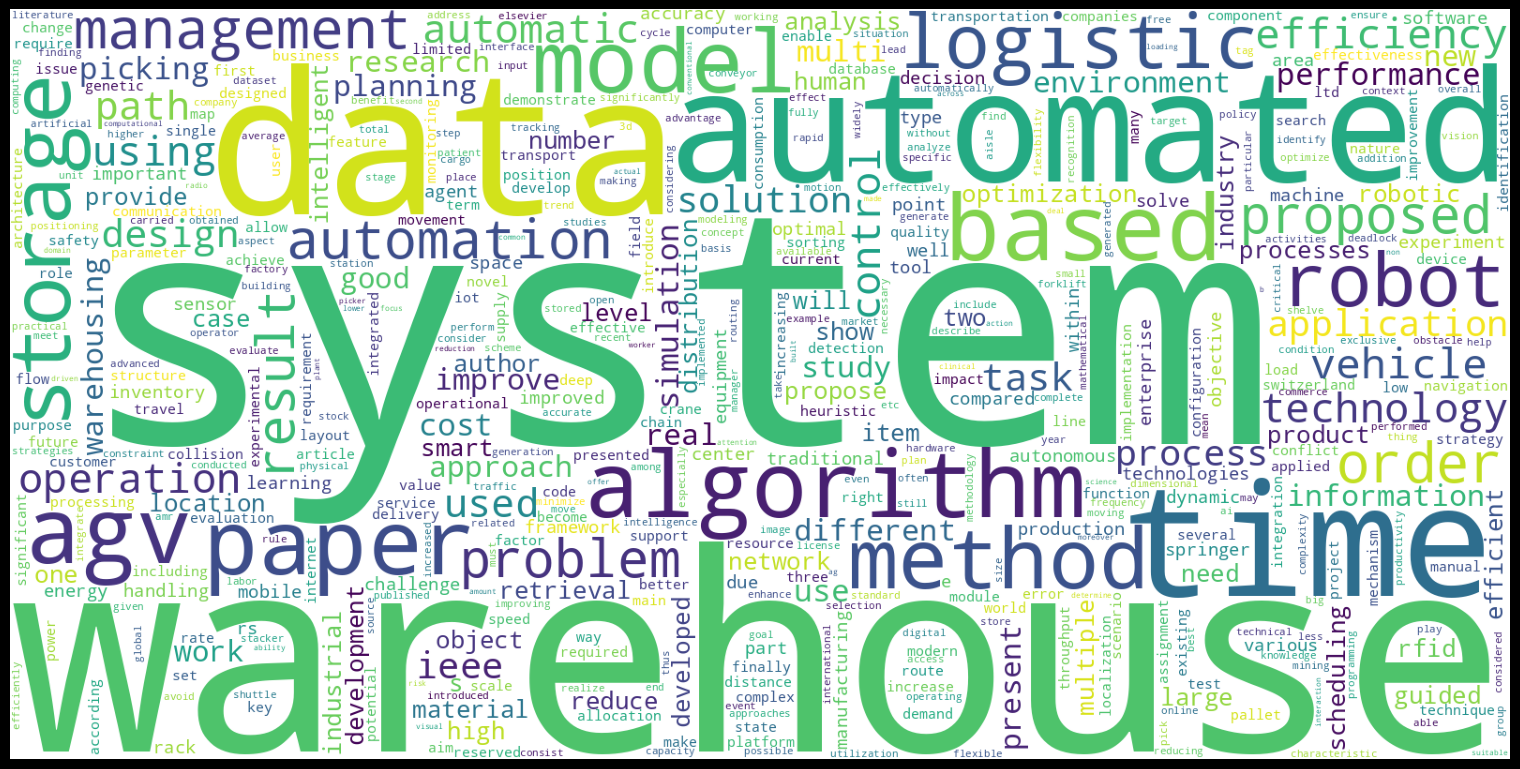

In [52]:
# WordCloud from the Abstracts, Title, Authors Keywords or Keywords Plus
# Arguments: entry             = 'abs', 'title', 'kwa', or 'kwp'
#            rmv_custom_words  = A list of custom stopwords to clean the corpus;
bibfile.word_cloud_plot(entry = 'abs', size_x = 15, size_y = 10, wordsn = 500, rmv_custom_words = [])

In [53]:
# Check Table
num_columns = 5
data_wd     = bibfile.ask_gpt_wd
items       = list(data_wd.items())

field_names = []
for i in range(num_columns):
    field_names.append(f"Word {i + 1}")
    field_names.append(f"Importance {i + 1}")

table = PrettyTable()
table.field_names = field_names

for i in range(0, len(items), num_columns):
    row = []
    for j in range(num_columns):
        if i + j < len(items):
            word, importance = items[i + j]
            row.extend([word, round(importance, 4)])
        else:
            row.extend(["", ""])
    table.add_row(row)

# Print the table
print(table)

+----------------+--------------+----------------+--------------+----------------+--------------+---------------+--------------+----------------+--------------+
|     Word 1     | Importance 1 |     Word 2     | Importance 2 |     Word 3     | Importance 3 |     Word 4    | Importance 4 |     Word 5     | Importance 5 |
+----------------+--------------+----------------+--------------+----------------+--------------+---------------+--------------+----------------+--------------+
|     system     |     1.0      |   warehouse    |    0.9092    |      data      |    0.4001    |   automated   |    0.3645    |      time      |    0.3638    |
|   algorithm    |    0.353     |      agv       |    0.3472    |     based      |    0.3442    |     paper     |    0.3367    |     model      |    0.3154    |
|    storage     |    0.2859    |     method     |    0.2771    |    logistic    |    0.2629    |     robot     |    0.2537    |   management   |    0.249     |
|     order      |    0.2436    | 

In [54]:
# N-Grams
# Arguments: view       = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window);
#            entry      = 'abs', 'title', 'kwa', or 'kwp'
#            n_grams    = An integer with size n (representing the most common groups of words with size n)
#            stop_words = A list of stopwords to clean the corpus. ['ar', 'bn', 'bg', 'cs', 'en', 'fi', 'fr', 'de', 'el', 'hi', 'he', 'hu', 'it', 'ja', 'ko',  'mr', 'fa', 'pl', 'pt-br', 'ro', 'ru', 'es', 'sv', 'sk', 'zh', 'th', 'uk'];
#                         'ar' = Arabic; 'bn' = Bengali; 'bg' = Bulgarian; 'cs' = Czech; 'en' = English; 'fi' = Finnish; 'fr' = French; 'de' = German; 'el' = Greek; 'he' = Hebrew;'hi' = Hindi; 'hu' = Hungarian; 'it' = Italian;
#                         'ja' = Japanese; 'ko' = Korean; 'mr' =  Marathi; 'fa' =  Persian; 'pl' =  Polish; 'pt-br' = Potuguese-Brazilian; 'ro' = Romanian; 'ru' = Russian; 'es' =  Spanish; 'sk' = Slovak; 'sv' = Swedish;
#                          'zh' = Chinese; 'th' = Thai; 'uk' = Ukrainian
#            rmv_custom_words  = A list of custom stopwords to clean the corpus
#             wordsn           = Number of N-Grams
bibfile.get_top_ngrams(view = 'notebook', entry = 'kwp', ngrams = 3, stop_words = [], rmv_custom_words = [], wordsn = 15)

In [55]:
# Check Table
data_ng = bibfile.ask_gpt_ng
data_table.DataTable(data_ng, num_rows_per_page = 15)

,Word,Freq
0,automatic guided vehicles,278
1,automated guided vehicles,197
2,storage and retrieval,100
3,radio frequency identification,96
4,and retrieval system,88
5,warehouses automated guided,83
6,internet of things,80
7,automated storage and,74
8,frequency identification rfid,68
9,computer control systems,66


In [56]:
# Documents Projection based on Words. (An interactive plot). It returns the Projection (each document coordinate) and the Labels (each document cluster)
# Arguments: view              = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window);
#            corpus_type       = 'abs', 'title', 'kwa', or 'kwp';
#            stop_words        = A list of stopwords to clean the corpus. ['ar', 'bn', 'bg', 'cs', 'en', 'fi', 'fr', 'de', 'el', 'hi', 'he', 'hu', 'it', 'ja', 'ko',  'mr', 'fa', 'pl', 'pt-br', 'ro', 'ru', 'es', 'sv', 'sk', 'zh', 'th', 'uk'];
#                                'ar' = Arabic; 'bn' = Bengali; 'bg' = Bulgarian; 'cs' = Czech; 'en' = English; 'fi' = Finnish; 'fr' = French; 'de' = German; 'el' = Greek; 'he' = Hebrew;'hi' = Hindi; 'hu' = Hungarian; 'it' = Italian;
#                                'ja' = Japanese; 'ko' = Korean; 'mr' =  Marathi; 'fa' =  Persian; 'pl' =  Polish; 'pt-br' = Potuguese-Brazilian; 'ro' = Romanian; 'ru' = Russian; 'es' =  Spanish; 'sk' = Slovak; 'sv' = Swedish;
#                                'zh' = Chinese; 'th' = Thai; 'uk' = Ukrainian
#            rmv_custom_words  = A list of custom stopwords to clean the corpus;
#            custom_label      = A list of custom labels for each document. The user can define each document cluster;
#            custom_projection = A list of custom coordinates for each document. The user can define each document coordinate;
#            n_components      = Number of Dimensions;
#            n_clusters        = Only relevant if  cluster_method = 'kmeans'.Number of Clusters.;
#            node_labels       = If True, labels appear in nodes;
#            node_size         = Node size;
#            node_font_size    = Node font size;
#            tf_idf            = True or False (True -> The Cluster Algorithm will use the DTM to calculate each document Label. False -> The Cluster Algorithm will use the Coordinates to calculate each document Label);
#            embeddings        = True or False (True -> The Cluster Algorithm will use the Word Embeddings to calculate each document Label. False -> The Cluster Algorithm will use the Coordinates to calculate each document Label);
#            model             = Only relevant if 'embeddings = True'. Specifies the used AI model. The default value is 'allenai/scibert_scivocab_uncased';
#            method            = 'tsvd' or 'umap' ('tsvd' -> Truncated SVD projection method is used. 'umap' -> UMAP projection method is used);
#            showlegend        = If True, shows legend;
#            cluster_method    = 'kmeans' or 'hdbscan';
#            min_size          = Only relevant if  cluster_method = 'hdbscan'. Minimum number of elements in a Cluster;
#            max_size          = Only relevant if  cluster_method = 'hdbscan'. Maximum number of elements in a Cluster
projection, labels = bibfile.docs_projection(view              = 'notebook',
                                             corpus_type       = 'abs',
                                             stop_words        = ['en'],
                                             rmv_custom_words  = [],
                                             custom_label      = [],
                                             custom_projection = [],
                                             n_components      = 2,
                                             n_clusters        = 5,
                                             node_labels       = True,
                                             node_size         = 20,
                                             node_font_size    = 10,
                                             tf_idf            = False,
                                             embeddings        = False,
                                             model             = 'allenai/scibert_scivocab_uncased',
                                             method            = 'umap',
                                             showlegend        = True,
                                             cluster_method    = 'kmeans',
                                             min_size          = 5,
                                             max_size          = 50
                                             )

In [57]:
# Check Table
data_pr = pd.DataFrame(np.hstack([projection, labels.reshape(-1,1)]))
data_table.DataTable(data_pr, num_rows_per_page = 15)

,0,1,2
0,7.772563,-1.915689,1.0
1,11.041981,1.158527,3.0
2,8.480690,-3.028907,2.0
3,7.228186,-1.158902,1.0
4,7.853136,-0.385695,1.0
...,...,...,...
1416,6.882969,2.462928,0.0
1417,8.183902,0.968227,3.0
1418,9.206059,-0.384366,3.0
1419,9.090660,1.617805,3.0


In [58]:
# Check Articles per Cluster
cluster      = 0
idx_articles = [i for i in range(0, labels.shape[0]) if labels[i] == cluster]
print(*idx_articles, sep = ', ')

46, 63, 68, 72, 76, 81, 85, 99, 133, 148, 157, 161, 173, 177, 208, 223, 237, 241, 251, 253, 284, 290, 294, 295, 314, 316, 323, 333, 336, 338, 341, 345, 348, 363, 365, 380, 390, 395, 441, 461, 471, 475, 487, 497, 507, 511, 523, 537, 538, 542, 543, 545, 559, 573, 602, 625, 633, 635, 637, 639, 650, 656, 664, 665, 666, 668, 684, 700, 710, 717, 718, 736, 745, 748, 751, 754, 764, 766, 771, 792, 794, 795, 801, 806, 809, 813, 818, 828, 852, 859, 869, 894, 907, 914, 921, 923, 925, 926, 931, 935, 949, 950, 951, 956, 958, 974, 983, 995, 996, 1004, 1014, 1018, 1019, 1020, 1028, 1031, 1037, 1038, 1042, 1065, 1072, 1076, 1085, 1099, 1100, 1118, 1120, 1121, 1131, 1137, 1138, 1139, 1147, 1150, 1156, 1161, 1164, 1167, 1170, 1180, 1182, 1183, 1193, 1201, 1204, 1221, 1224, 1233, 1234, 1239, 1243, 1244, 1246, 1262, 1263, 1266, 1273, 1275, 1282, 1283, 1286, 1308, 1313, 1316, 1317, 1322, 1325, 1329, 1331, 1333, 1344, 1348, 1360, 1369, 1376, 1380, 1384, 1386, 1387, 1395, 1398, 1399, 1401, 1409, 1410, 1415, 1

In [59]:
# Arguments: view              = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window);
#            key               = 'abs', 'title', 'jou, 'kwa', or 'kwp';
#            stop_words        = A list of stopwords to clean the corpus. ['ar', 'bn', 'bg', 'cs', 'en', 'fi', 'fr', 'de', 'el', 'hi', 'he', 'hu', 'it', 'ja', 'ko',  'mr', 'fa', 'pl', 'pt-br', 'ro', 'ru', 'es', 'sv', 'sk', 'zh', 'th', 'uk'];
#                                'ar' = Arabic; 'bn' = Bengali; 'bg' = Bulgarian; 'cs' = Czech; 'en' = English; 'fi' = Finnish; 'fr' = French; 'de' = German; 'el' = Greek; 'he' = Hebrew;'hi' = Hindi; 'hu' = Hungarian; 'it' = Italian;
#                                'ja' = Japanese; 'ko' = Korean; 'mr' =  Marathi; 'fa' =  Persian; 'pl' =  Polish; 'pt-br' = Potuguese-Brazilian; 'ro' = Romanian; 'ru' = Russian; 'es' =  Spanish; 'sk' = Slovak; 'sv' = Swedish;
#                                'zh' = Chinese; 'th' = Thai; 'uk' = Ukrainian
#            rmv_custom_words  = A list of custom stopwords to clean the corpus;
#            topn              = Total number entities;
#            txt_font_size     = Font size of the text inside the bins;
#            start             = Start Year; -1 = all years
#            end               = End Year;   -1 = all years
bibfile.plot_evolution_year(view             = 'notebook',
                            stop_words       = [],
                            rmv_custom_words = [],
                            key              = 'kwa',
                            topn             = 10,
                            txt_font_size    = 12,
                            start            = 2009,
                            end              = 2025)

In [60]:
# View Table
data_ep = bibfile.ask_gpt_ep

# Check if data_ep is a pandas DataFrame before trying to display it as a table.
# If it's an integer, it likely means no data was returned or an error occurred.
if isinstance(data_ep, pd.DataFrame):
    data_table.DataTable(data_ep, num_rows_per_page = 15)
else:
    print(f"Data for evolution plot is not available or returned an error code: {data_ep}. Expected a DataFrame.")


Data for evolution plot is not available or returned an error code:  2009: automation (4), logistics (3), warehouse (3), rfid (3), simulation (3), order picking (3), automated warehouse (2), data mining (2), optimization (2), automated storage and retrieval systems (2) 2010: logistics (5), simulation (4), automation (3), data mining (3), warehouses (3), rfid (3), automated warehouse (2), automated storage and retrieval system (2), order picking (2), split-platform automated storage/retrieval system (2) 2011: automated warehouse (5), genetic algorithm (3), logistics (2), data mining (2), integrated scheduling (2), olap (2), simulation (1), path planning (1), rfid (1), automated guided vehicles (1) 2012: logistics (3), simulation (3), automated warehouse (3), rfid (3), discrete event systems (3), petri nets (3), optimization (2), intelligent warehouse (2), warehouse (2), management (2) 2013: automated warehouse (5), simulation (4), data mining (4), warehouse management (3), automation (2

In [61]:
# Arguments: view              = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window);
#            topn              = Most frequent n words
#            custom            = Plot specific words
bibfile.plot_evolution_year_complement(data_ep, view = 'notebook', topn = 10, custom = [])

In [95]:
# Sankey Diagram (An interactive plot)
# Arguments:
#   view         : Determines the rendering mode.'notebook' -> Plots in your preferred Notebook app. 'browser'  -> Plots in your preferred browser window.
#   entry        : A list defining the sequence of data columns to be visualized. Allowed keys: 'aut', 'cout', 'inst', 'jou', 'kwa', 'kwp', 'lan'
#   rmv_unknowns : Boolean flag controlling how unknown entries are handled. True  -> Remove any relationships that include 'unknown'.
#   topn         : Specifies the maximum number of top entities/connections to display at each level. Set to "None" for no filtering or provide a list with limits corresponding to each connection between the nodes defined in 'entry'.
bibfile.sankey_diagram(view = 'notebook', entry = ['kwa', 'cout', 'kwp'], topn = [2, 3], rmv_unknowns = True)

# PS: The white bars can be dragged

In [63]:
# View Table
data_sk = bibfile.ask_gpt_sk
data_table.DataTable(data_sk, num_rows_per_page = 15)

,Node From,Node To,Connection Weigth
0,"basile, francesco",France,14
1,"chiacchio, pasquale",France,12
2,"chiacchio, pasquale",Italy,2
3,"lerher, tone",Slovenia,9
4,France,english,134
5,Italy,english,374
6,Slovenia,english,28


In [64]:
# Plot Count Y per X (An interactive bar chart)
# Arguments:
#   view          : Determines where the plot will be rendered. 'browser'  -> Plots in your preferred browser window. 'notebook' -> (if supported) Plots within your notebook environment.
#   rmv_unknowns  : Boolean flag to handle unknown entries. True  -> Removes any relationships containing unknown values.
#   x             : The key (column) to use for the X-axis. Must be one of: 'aut', 'cout', 'inst', 'jou', 'kwa', 'kwp', 'lan'. Default is 'cout'.
#   y             : The key (column) to use for the Y-axis. Must be one of: 'aut', 'cout', 'inst', 'jou', 'kwa', 'kwp', 'lan'. Default is 'aut'.
#   topn_x        : Maximum number of top X categories (based on total counts) to display. Default is 5.
#   topn_y        : Maximum number of top Y entries (per X category) to display. Default is 5.
#   text_font_size: Font size for the text labels displayed inside the bars. Default is 12.
#   x_angle       : Angle (in degrees) for the X-axis tick labels. Default is -90 (rotating labels vertically).
bibfile.plot_count_y_per_x(view = 'notebook', rmv_unknowns = True, x = 'cout', y = 'aut', topn_x = 5, topn_y = 5, text_font_size = 12, x_angle = -90)

In [65]:
# View Table
data_table.DataTable(bibfile.top_y_x, num_rows_per_page = 15)

,Count,X (Countries),Y (Authors)
603,7,China,"wu, weimin"
1306,6,China,"wu, yaohua"
442,5,China,"zhang, zheng"
1954,5,China,"wang, yong"
159,4,China,"zhang, bo"
843,5,Germany,"boysen, nils"
2074,3,Germany,"fottner, johannes"
2323,3,Germany,"müller, marcel"
3901,3,Germany,"röhrig, christof"
135,2,Germany,"lorson, fabian"


In [83]:
# Plot Heatmap Y per X (An interactive bar chart)
# Arguments:
#   view          : Determines where the plot will be rendered. 'browser'  -> Plots in your preferred browser window. 'notebook' -> (if supported) Plots within your notebook environment.
#   rmv_unknowns  : Boolean flag to handle unknown entries. True  -> Removes any relationships containing unknown values.
#   x             : The key (column) to use for the X-axis. Must be one of: 'aut', 'cout', 'inst', 'jou', 'kwa', 'kwp', 'lan'. Default is 'cout'.
#   y             : The key (column) to use for the Y-axis. Must be one of: 'aut', 'cout', 'inst', 'jou', 'kwa', 'kwp', 'lan'. Default is 'aut'.
#   topn_x        : Maximum number of top X categories (based on total counts) to display. Default is 5.
#   topn_y        : Maximum number of top Y entries (per X category) to display. Default is 5.
#   element_x     : Custom list of elements in X-axis
#   element_y     : Custom list of elements in Y-axis
bibfile.plot_heatmap_y_per_x(x = 'kwa', y = 'cout', topn_x = 15, topn_y = 5, element_x = [], element_y = [], rmv_unknowns = True, view = "notebook")

In [84]:
# View Table
data_table.DataTable(bibfile.heat_y_x, num_rows_per_page = 15)

,automation,warehouse automation,warehouse,logistics,automated warehouse,agv,warehousing,path planning,simulation,industry 4.0,rfid,deep learning,automated guided vehicles,iot,optimization
China,"[225, 567, 390, 73, 458, 973, 142, 879, 304, 4...","[0, 3, 201, 557, 110, 303, 653, 1389, 885, 568...","[610, 1251, 144, 1140, 916, 757, 1142]","[1251, 356, 811, 843, 1355, 142, 304, 1169, 24...","[1413, 1414, 1287, 264, 908, 1295, 1301, 408, ...","[518, 7, 138, 659, 20, 793, 409, 412, 291, 553...","[641, 549, 843, 1393, 306, 1403, 250, 91, 540,...","[128, 258, 387, 138, 1274, 144, 533, 152, 154,...","[1095, 777, 714, 1385, 1324, 911, 1371, 883, 4...","[236, 871]","[1287, 765, 1162, 1419, 782, 784, 401, 1169, 1...","[912, 44, 271]","[121, 2, 386, 249, 199, 104, 1207, 89, 61]","[153, 434, 1093, 626]","[1187, 356, 1061, 1385, 1371, 189]"
Italy,"[1218, 1196, 1197, 1390, 1111, 1372]","[1158, 1066, 663, 798, 799]","[829, 860, 741, 959]","[937, 1388, 1390, 787, 723, 405, 1055]","[581, 1160, 429, 238, 1390, 374, 92]","[346, 1155, 1158]","[1218, 1124, 332, 1196, 1388, 946, 1111, 985, ...",[844],"[1218, 937, 1196, 238, 946, 374]","[512, 856, 581, 429]","[1160, 959]",[],"[89, 1074, 582]",[],"[937, 267]"
India,"[64, 168, 488, 301, 206, 205, 751, 402, 795]","[928, 483, 485, 71, 40, 618, 939, 23, 156, 350...","[64, 516, 998, 168, 617, 331, 12, 402, 1398, 7...","[402, 1109, 261, 206]",[1126],"[329, 594]",[594],"[400, 276, 350, 23]",[1109],"[928, 939]","[338, 319]","[483, 668, 671]","[104, 563, 372]","[64, 644, 71, 428, 269, 57, 795]","[1186, 212, 206, 215]"
United States of America,"[164, 4, 68, 923, 935, 395, 240, 695, 729, 379]","[164, 388, 485, 103, 967, 1001, 1060, 16, 209,...","[1357, 829, 895]","[4, 967, 107, 715, 1109, 927]","[482, 229, 581, 111, 52, 159]","[465, 111]","[306, 715, 4]","[16, 1060, 844, 414]","[955, 1109, 1095]","[482, 581, 229, 395, 240]","[107, 1357]",[848],[61],"[99, 395]","[513, 159]"
Germany,"[551, 814, 530, 948, 727]","[904, 1328, 1299, 632, 1214]",[615],"[545, 1412, 297, 814, 1104, 242, 1146]",[36],"[460, 686, 1215]","[224, 545, 515, 1029, 358, 552, 905, 460, 81, ...",[],"[936, 1214]",[],[1146],"[632, 545]","[552, 1299, 460]",[99],[948]


In [68]:
# Tree Map
# Arguments: view          = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window);
#            entry         = 'kwp', 'kwa', 'aut', 'jou', 'ctr', or 'inst';
#            topn          = Total number entities
#            txt_font_size = Font size of the text inside the bins;
bibfile.tree_map(view = 'notebook', entry = 'jou', topn = 20)

In [97]:
# Authors Productivity Plot (An interactive plot). It informs for each year the documents (IDs) published for each author
# Arguments: view = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window);
#            topn = Total number entities
bibfile.authors_productivity(view = 'notebook', topn = 20)

Error: could not locate runnable browser

In [70]:
# View Table
data_ap = bibfile.ask_gpt_ap
data_table.DataTable(data_ap, num_rows_per_page = 15)

,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
"chiacchio, pasquale",2.0,0.0,2.0,3.0,0.0,0.0,1.0,2.0,1.0,1.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0
"basile, francesco",2.0,0.0,2.0,3.0,0.0,0.0,1.0,2.0,1.0,1.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0
"lerher, tone",0.0,1.0,1.0,0.0,0.0,0.0,2.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0
"sabattini, lorenzo",0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,1.0,0.0
"wu, yaohua",0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
"wu, weimin",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,2.0,1.0,1.0,0.0
"wang, qian",0.0,3.0,0.0,0.0,0.0,1.0,0.0,2.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"janilionis, vytautas v.",1.0,2.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"coppola, jolanda",0.0,0.0,2.0,2.0,0.0,0.0,1.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"secchi, cristian",0.0,0.0,0.0,0.0,0.0,1.0,2.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [71]:
# Countries Productivity Plot (An interactive plot). It informs the production for each Country (count is made considering each doc author)
# Arguments: view = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window);
bibfile.countries_productivity(view = 'notebook')

In [72]:
# View Table
data_cp = bibfile.ask_gpt_cp
data_table.DataTable(data_cp, num_rows_per_page = 15)

,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,All Years
china,28,42,32,48,59,46,25,29,51,84,90,147,167,171,169,177,84,1449
united states of america,19,14,7,10,0,0,19,15,19,23,42,47,45,62,28,49,35,434
italy,14,5,12,8,17,23,24,18,9,16,46,27,63,21,25,22,24,374
india,0,1,0,0,6,0,2,19,13,29,18,33,43,45,43,49,30,331
germany,4,10,5,6,8,15,13,4,25,27,17,15,47,7,23,21,7,254
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
moldova,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1
ecuador,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1
estonia,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1
ghana,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1


In [73]:
# Institutions Productivity Plot (An interactive plot). It informs for each year the documents (IDs) published for each institution
# Arguments: view = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window);
#            topn = Total number entities
bibfile.institution_productivity(view = 'notebook', topn = 20)

In [74]:
# View Table
data_ip = bibfile.ask_gpt_ip
data_table.DataTable(data_ip, num_rows_per_page = 15)

,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
francesco università degli studi di salerno,2.0,0.0,2.0,3.0,0.0,0.0,1.0,2.0,1.0,1.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0
alice università di pisa,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
elena galbally stanford university,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
carlos tu delft robotics institute,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
song universidad politécnica de madrid,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
anh nhat fpt university,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
ajay k. tcs research,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,2.0,1.0,0.0,0.0,0.0,0.0,0.0
andrea politecnico di torino,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,2.0,0.0
antonio f. fisheries and food research,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
sungkyunkwan univ,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0


In [75]:
# Sources Productivity Plot (An interactive plot). It informs for each year the documents (IDs) published for each source (journal)
# Arguments: view = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window);
#            topn = Total number entities
bibfile.source_productivity(view = 'notebook', topn = 20)

In [76]:
# View Table
data_sp = bibfile.ask_gpt_sp
data_table.DataTable(data_sp, num_rows_per_page = 15)

,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
lect. notes comput. sci.,4.0,1.0,3.0,3.0,1.0,0.0,1.0,0.0,2.0,0.0,4.0,4.0,3.0,1.0,0.0,0.0,2.0
lect. notes electr. eng.,0.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,6.0,1.0,1.0,2.0,4.0,2.0,3.0
acm int. conf. proc. ser.,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,2.0,3.0,3.0,4.0,3.0,2.0,1.0,3.0,0.0
int j prod res,0.0,1.0,1.0,1.0,2.0,1.0,0.0,1.0,0.0,4.0,1.0,1.0,2.0,3.0,1.0,0.0,3.0
ieee access,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,3.0,2.0,1.0,7.0,5.0
appl. mech. mater.,0.0,0.0,1.0,4.0,7.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
proc spie int soc opt eng,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0,6.0,5.0,3.0,1.0
ifac-papersonline,0.0,0.0,0.0,0.0,0.0,0.0,3.0,1.0,0.0,0.0,5.0,1.0,3.0,3.0,1.0,1.0,0.0
j. phys. conf. ser.,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,7.0,5.0,2.0,1.0,0.0,0.0
"ieee int. conf. emerging technol. factory autom., etfa",0.0,0.0,0.0,0.0,1.0,0.0,2.0,2.0,1.0,2.0,2.0,2.0,2.0,2.0,0.0,0.0,0.0


In [77]:
# Bar Plots
# Arguments: view = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window);
#                    statistic = 'dpy', 'cpy', 'ppy', 'ltk', 'spd', 'spc', 'apd', 'apc', 'aph', 'bdf_1', 'bdf_2', 'bdf_3', 'ipd', 'ipc', 'cpd', 'cpc', 'lpd', 'kpd', 'kad'
#                        'dpy' = Documents per Year
#                         cpy' = Citations per Year
#                        'ppy' = Past Citations per Year
#                        'ltk' = Lotka's Law
#                        'spd' = Sources per Documents
#                        'spc' = Sources per Citations
#                        'apd' = Authors per Documents
#                        'apc' = Authors per Citations
#                        'aph' = Authors per H-Index
#                        'bdf_1', 'bdf_2', 'bdf_3' = Bradford's Law - Core Sources 1, 2 or 3
#                        'ipd' = Institutions per Documents
#                        'ipc' = Institutions per Citations
#                        'cpd' = Countries per Documents
#                        'cpc' = Countries per Citations
#                        'lpd' = Language per Documents
#                        'kpd' = Keywords Plus per Documents
#                        'kad' = Authors' Keywords per Documents
#                         topn = Total number entities
bibfile.plot_bars(view = 'notebook', statistic = 'apd', topn = 20)

In [78]:
# View Table
data_bp = bibfile.ask_gpt_bp
data_table.DataTable(data_bp, num_rows_per_page = 15)

,Documents,Authors
0,"chiacchio, pasquale",14
1,"basile, francesco",14
2,"lerher, tone",9
3,"sabattini, lorenzo",8
4,"wu, yaohua",7
5,"wu, weimin",7
6,"wang, qian",7
7,"janilionis, vytautas v.",7
8,"coppola, jolanda",7
9,"secchi, cristian",6


In [79]:
# Plot Top References
# Arguments: view       = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window);
#            topn       = Specifies the number of top references (by citation count) to display in the plot;
#            font_size  = Controls the font size of the legend in the plot;
#            use_ref_id = Chooses between using reference names or reference IDs when processing and plotting data;
#            date_start = If provided, shows citing articles with a publication year greater than or equal to this value are included. If None, then there is no lower limit on the publication year.
#            date_end   = If provided, shows citing articles with a publication year less than or equal to this value are included. If None, then there is no upprer limit on the publication year.
bibfile.plot_top_refs(view = 'notebook', topn = 10, font_size = 10, use_ref_id = False, date_start = None, date_end = None)

In [80]:
# Check Top References
data_table.DataTable(bibfile.top_refs, num_rows_per_page = 15)

# PS: Optionally, use 'bibfile.merge_reference(get = [], replace_for = 'name' )' to correct References
# wrong_references = [
#                     'Mousseau, V., Slowinski, R., Inferring an ELECTRE TRI model from assignment examples (1998) Journal of Global Optimization, 12, pp. 157-174',
#                     'Mousseau, V., Słowiński, R., Inferring an ELECTRE TRI model from assignment examples (1998) Journal of Global Optimization, 12 (2), pp. 157-174'
#                    ]
# correct_reference = 'Mousseau, V., Slowinski, R., Inferring an ELECTRE TRI model from assignment examples (1998) Journal of Global Optimization, 12 (2), pp. 157-174'
# bibfile.merge_reference(get = wrong_references, replace_for = correct_reference)

,Reference,Reference ID,Reference Year,Raw Citation Counts
0,"[Anonymous], About us.",r_614,-1,3
1,"Azadeh K, 2019, TRANSPORT SCI, V53, P917, DOI ...",r_35,2019,2
2,"Calzavara M, 2019, INT J PROD ECON, V210, P199...",r_72,2019,2
3,"Custodio L, 2020, INT J ADV MANUF TECH, V106, ...",r_121,2020,2
4,"Dukic G, 2015, INT J PROD ECON, V170, P874, DO...",r_151,2015,2
5,"Lenoble N, 2018, LECT NOTES BUS INF P, V262, P...",r_328,2018,2
6,"Meller RD, 2004, IIE TRANS, V36, P725, DOI 10....",r_384,2004,2
7,"Rosi B, 2016, INT J SIMUL MODEL, V15, P97, DOI...",r_461,2016,2
8,"Tresca G, 2022, IEEE T AUTOM SCI ENG, V19, P15...",r_534,2022,2
9,"Dallari F, 2009, INT J ADV MANUF TECH, V42, P1...",r_127,2009,2


In [81]:
# Citation Trajectory
# Arguments: view     = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window);
#           ref_names = If provided (i.e., nonempty), the function uses these reference names to track and plot citation trajectories;
#           ref_ids   = If ref_names is empty but ref_ids is provided, the function will use these IDs instead.
bibfile.plot_citation_trajectory(view = 'notebook', ref_names = [], ref_ids = ['r_6583', 'r_2738'])

In [82]:
# References Citation Matrix
# Arguments: tgt_ref_id = For a nonempty list, show olny the references in the list. An empty list (the default), shows all references;
#            date_start = If provided, shows citing articles with a publication year greater than or equal to this value are included. If None, then there is no lower limit on the publication year;
#            date_end   = If provided, shows citing articles with a publication year less than or equal to this value are included. If None, then there is no upprer limit on the publication year.
ct_matrix = bibfile.ref_citation_matrix(tgt_ref_id = ['r_6583', 'r_2738'], date_start = None, date_end = None)

# Check Citation Matrix. Citing Articles are in the format (Article ID, Year)
ct_matrix

KeyError: 'Reference'

In [ ]:
# RPYS (Reference Publication Year Spectroscopy) with Gaussian Filter to Find Peaks
# Arguments: view       = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window);
#            peaks_only = If False, the function plots data for all publication years. If True, shows only peaks.
bibfile.plot_rpys(view = 'notebook', peaks_only = False)

# PS: Use the Slider to focus in a range of years

In [ ]:
# Check RPYS Data
data_table.DataTable(bibfile.rpys_rs, num_rows_per_page = 15)

In [ ]:
# Check RPYS Data Peaks
data_table.DataTable(bibfile.rpys_pk, num_rows_per_page = 15)

# Network Analysis
---
In this section, we will perform Network Analysis

In [ ]:
# References Top Cited Co-References
# Arguments: groups = controls how many references are considered together;
#            topn   = Specifies the number of top references (by citation count) to display in the plot;
co_cited = bibfile.top_cited_co_references(group = 2, topn = 10)
co_cited

In [ ]:
# Plot Co-Citation Network
# Arguments:  view       = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window);
#             tgt_ref_id = The reference ID;
#             topn       = Specifies the number of top references (by citation count) to display in the plot;
bibfile.plot_co_citation_network(view = 'notebook', target_ref_id = 'r_6587', topn = 10)

In [ ]:
# Check Co-Citation Network
data_table.DataTable(bibfile.top_co_c, num_rows_per_page = 15)

In [ ]:
# SALSA (Stochastic Approximation for Local Search in Assignment Problems)
# Arguments: max_iter    = Maximum number of iterations for the iterative hub-authority computation;
#            tol         = Convergence tolerance. If changes in hub/authority vectors are smaller than this, the iterations stop early;
#            topn_decade = Number of top nodes (by hub/authority score) to return per decade.
result, top_by_decade_a, top_by_decade_h =  bibfile.salsa(max_iter = 150, tol = 1e-6, topn_decade = 5)

In [ ]:
# Top n Hubs (A hub is a paper that cites good sources like review articles)
n        = 10
sorted_h = np.argsort(result['hubs'])[::-1]
for idx in sorted_h[:n]:
    print('Node:', result['node_ids'][idx], '( Hub Score =', result['hubs'][idx], ')')

In [ ]:
# Top n Hubs - Decade
for decade in sorted(top_by_decade_h.keys()):
    print(f"\nTop Hub Nodes in the {decade}s:")
    for node_id, hub_score in top_by_decade_h[decade]:
        print(f"  Node: {node_id} ( Hub Score: {hub_score:.16f} )")

In [ ]:
# Top n Authorities (An authority is a frequently cited paper by influential papers)
n        = 10
sorted_a = np.argsort(result['authorities'])[::-1]
for idx in sorted_a[:n]:
    print('Node:', result['node_ids'][idx], '( Authority Score =', result['authorities'][idx], ')')

In [ ]:
# Top n Authorities  - Decade
for decade in sorted(top_by_decade_a.keys()):
    print(f"\nTop Authorithy Nodes in the {decade}s:")
    for node_id, auth_score in top_by_decade_a[decade]:
        print(f"  Node: {node_id} ( Authority Score: {auth_score:.7f} )")

In [ ]:
# Sleeping Beauties
# Arguments: topn      = Number of top Sleeping Beauties to return (ranked by beauty coefficient B);
#            min_count = Minimum total number of citations for a reference to be considered a candidate. Filters out low-impact papers.
sleeping_beauties = bibfile.detect_sleeping_beauties(topn = 10, min_count = 5)

In [ ]:
# Print results
# c0  =	Citations in the first year it was cited.
# cm  =	Maximum number of citations in a single year.
# t_m =	Time to reach cm (years from first citation).
# t_a =	Awakening time, year when the deviation is maximum (most "asleep").
# B	  = Beauty coefficient, how much the real citation trajectory deviates below a "ramp" leading to the peak.
# SBI = Normalized B (~0	Not a sleeping beauty; 0.1–0.3	Mild sleeper; 0.4–0.6	Noticeable sleeper; 0.7+	Strong sleeper — classic "Sleeping Beauty").
data_table.DataTable(sleeping_beauties, num_rows_per_page = 15)

In [ ]:
# Princes
princes = bibfile.detect_princes(sleeping_beauties)

In [ ]:
# Print Results
data_table.DataTable(princes, num_rows_per_page = 15)

In [ ]:
# Arguments:
# entry      = 'aut', 'cout', 'inst', 'kwa', or 'kwp'.
# tgt        = List of specific names.
# topn       = Integer. Specifies the number of top authors to display based on their total contributions.
# rows       = Integer. Defines the number of rows in the subplot grid for the visual layout.
# cols       = Integer. Defines the number of columns in the subplot grid for the visual layout.
# wspace     = Float. Adjusts horizontal spacing between subplots.
# hspace     = Float. Adjusts vertical spacing between subplots.
# tspace     = Float. Sets additional vertical space between nodes and labels for better readability.
# node_size  = Integer. Controls the size of each node in the network graph.
# font_size  = Integer. Defines the font size for node labels.
# pad        = Float. Adjusts padding around the layout for a balanced appearance.
# nd_a       = Color string (e.g., '#FF0000'). Specifies the color for the primary node (main author).
# nd_b       = Color string (e.g., '#008000'). Specifies the color for secondary nodes (authors with significant links).
# nd_c       = Color string (e.g., '#808080'). Specifies the color for other nodes (authors with minor links).
# verbose    = Boolean. If True, prints details of each main node and its connections in the console; if False, suppresses this output.
bibfile.network_collab( entry     = 'aut',
                        tgt       = [],
                        topn      = 15,
                        rows      = 5,
                        cols      = 3,
                        wspace    = 0.2,
                        hspace    = 0.2,
                        tspace    = 0.01,
                        node_size = 300,
                        font_size = 8,
                        pad       = 0.2,
                        nd_a      = '#FF0000',
                        nd_b      = '#008000',
                        nd_c      = '#808080',
                        verbose   = False)

In [ ]:
print(bibfile.ask_gpt_ct)

In [ ]:
# Network - Citation Analisys Between Documents (Blue Nodes) and Citations (Red Nodes).  (An interactive plot).
# Arguments: view        = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window);
#            min_count   = Relationship between nodes that have been cited at least x times;
#            node_labels = True or False (True -> The label IDs will be displayed, False -> Only the nodes will be displayed );
#            node_size   = Integer. Value for node size;
#            font_size   = Integer. Defines the font size for node labels;
#            local_nodes = True or False (True -> Only the blue will be displayed, False -> Red and Blue nodes will be displayed)
bibfile.network_adj_dir(view = 'notebook', min_count = 25, node_labels = True, node_size = 20, font_size = 10, local_nodes = False)

In [ ]:
# View Table
data_nad = bibfile.ask_gpt_nad
data_table.DataTable(data_nad, num_rows_per_page = 15)

In [ ]:
# Network - Highlight Citation Analysis Between Documents (Blue Nodes) and Citations (Red Nodes).  (An interactive plot).
# Arguments: view        = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window);
#            article_ids = A list of Blue Nodes. It indicates the documents cited by them;
#            ref_ids     = A list of Red Nodes. It indicates the documents that cites them;
#            font_size   = Integer. Defines the font size for node labels;
#            node_size   = Integer. Value for node size;
bibfile.find_nodes_dir(view = 'notebook', article_ids = ['283'], ref_ids = [], node_size = 20, font_size = 10)

In [ ]:
# Network - Highlight Citation Analysis Between Documents (Blue Nodes) and Citations (Red Nodes).  (An interactive plot).
# Arguments: view        = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window);
#            article_ids = A list of Blue Nodes. It indicates the documents cited by them;
#            ref_ids     = A list of Red Nodes. It indicates the documents that cites them;
#            font_size   = Integer. Defines the font size for node labels;
#            node_size   = Integer. Value for node size
bibfile.find_nodes_dir(view = 'notebook', article_ids = [], ref_ids = ['r_2738'], node_size = 20, font_size = 10)

In [ ]:
# Network - Local Documents (Only Blue Nodes) Citation History. (An interactive plot).
# Arguments: view        = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window);
#            min_links   = Relationship between nodes that have connected at least x times;
#            node_size   = Integer. Value for node size;
#            font_size   = Integer. Defines the font size for node labels;
#            node_labels = True or False (True -> The label IDs will be displayed, False -> Only the nodes will be displayed );
#            chain       = A list of documents. It shows the documents and their citations;
#            path       =  Only relevant if 'chain' is not empty. True -> Show only the documents in 'chain'. False -> Show documents and connections.
citations = bibfile.network_hist(view = 'notebook', min_links = 1, chain = [], path = False, node_size = 20, font_size = 10, node_labels = True)

In [ ]:
# View Table
data_hist = bibfile.ask_gpt_hist
data_table.DataTable(data_hist, num_rows_per_page = 15)

In [ ]:
citations = bibfile.network_hist(view = 'notebook', min_links = 1, chain = [21, 208, 261], path = False, node_size = 20, font_size = 10, node_labels = True)

In [ ]:
citations = bibfile.network_hist(view = 'notebook', min_links = 1, chain = [3, 8, 56, 84, 120, 248], path = True, node_size = 20, font_size = 10, node_labels = True)

In [ ]:
# Network - Analyze Hist. Citations
# Arguments: min_path_size = Minimum number of elements of a path.
hist_paths = bibfile.analyze_hist_citations(citations, min_path_size = 2)

In [ ]:
# Network - Collaboration Analysis Between Authors, Countries, Intitutions Or Adjacency Analysis Between Authors' Keywords or Keywords Plus. (An interactive plot).
# Arguments: view        = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window);
#            adj_type    = 'aut', 'cout', 'inst', 'kwa', or 'kwp'
#            min_count   = Relationship between nodes that have connected at least x times;
#            node_labels = True or False (True -> The label IDs will be displayed, False -> Only the nodes will be displayed );
#            node_size   = -1. (If node_size = -1 then the default value will be used. If node_size > 0 then this new value will be used);
#            label_type  = 'id', 'name' (Only meaningfull if node_labels = True. 'id' -> The ID will be displayed; 'name' -> The name will be displayed);
#            centrality  = 'degree', 'load', 'betw', 'close', 'eigen', 'katz', 'harmonic', or None. Color nodes according to centrality criterion
#                          'degree'   = Degree Centrality
#                          'load'     = Load Centrality
#                          'betw'     = Betweenness Centrality
#                          'close'    = Closeness Centrality
#                          'eigen'    = Eigenvector Centrality
#                          'katz'     = Katz Centrality
#                          'harmonic' = Harmonic Centrality
#                           None      = The Community Algorithm, Girvan-Newman, will be used Instead of a Centrality Criterion
bibfile.network_adj(view = 'notebook', adj_type = 'aut', min_count = 5, node_labels = True, label_type = 'name', centrality = None)

# PS: If a centrality criterion is used then the values can be obtained by the following command:  bibfile.table_centr

In [ ]:
# View Table
data_adj = bibfile.ask_gpt_adj
data_table.DataTable(data_adj, num_rows_per_page = 15)

In [ ]:
# Network - Highlight  Collaboration Analysis Between Authors, Countries, Intitutions Or Adjacency Analysis Between Authors' Keywords or Keywords Plus. (An interactive plot).
# Arguments: view      = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window);
#            node_ids  = A list of IDs. Only meaningfull if label_type = 'id';
#            node_name = A list of Names. Only meaningfull iflabel_type = 'name';
#            node_only = True or False (True -> Only the Node will be Highlighted, False -> Node and its Connections will be Highlighted)
bibfile.find_nodes(node_ids = [], node_name = ['dias, l.c.'], node_only = False)

In [ ]:
# Network - Similarity Analysis using coupling or cocitation methods. (An interactive plot).
# Arguments: view        = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window);
#            sim_type    = 'coup', 'cocit' ('coup' -> Coupling Method, 'cocit' -> Cocitation Method)
#            node_size   = -1. (If node_size = -1 then the default value will be used. If node_size > 0 then this new value will be used);
#            node_labels = True or False (True -> The label IDs will be displayed, False -> Only the nodes will be displayed );
#            cut_coup    = Cutoff value for Coupling Method. Only meaninfull if sim_type = 'coup';
#            cut_cocit   = Cutoff value for Cocitation Method. Only meaninfull if sim_type = 'cocit'
bibfile.network_sim(view = 'notebook', sim_type = 'cocit', node_size = 10, node_labels = True, cut_coup = 0.3, cut_cocit = 10)

In [ ]:
# Check Similarity Values
data_table.DataTable(bibfile.sim_table, num_rows_per_page = 15)

In [ ]:
# Network - Collaboration Analysis Between Countries using a Map. (An interactive plot).
# Arguments: view        = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window);
#            connections = True or False (True -> Countries connections will be displayed, False -> Countries connections will not be displayed);
#            country_lst = Highlight the Connections Between a List of Countries
bibfile.network_adj_map(view = 'notebook', connections = True, country_lst = [])

In [ ]:
# View Table
data_map = bibfile.ask_gpt_map
data_table.DataTable(data_map, num_rows_per_page = 15)

In [ ]:
# Network - Collaboration Analysis Between Countries using a Map. (An interactive plot).
# Arguments: view        = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window);
#            connections = True or False (True -> Countries connections will be displayed, False -> Countries connections will not be displayed);
#            country_lst = Highlight the Connections Between a List of Countries
bibfile.network_adj_map(view = 'notebook', connections = False, country_lst = ['Mexico'])

# Artificial Intelligence Analysis
---
In this section, we will perform AI Analysis

In [ ]:
# NLP
# Arguments: corpus_type       = 'abs', 'title', 'kwa', or 'kwp';
#            stop_words        = A list of stopwords to clean the corpus. ['ar', 'bn', 'bg', 'cs', 'en', 'fi', 'fr', 'de', 'el', 'hi', 'he', 'hu', 'it', 'ja', 'ko',  'mr', 'fa', 'pl', 'pt-br', 'ro', 'ru', 'es', 'sv', 'sk', 'zh', 'th', 'uk'];
#                                'ar' = Arabic; 'bn' = Bengali; 'bg' = Bulgarian; 'cs' = Czech; 'en' = English; 'fi' = Finnish; 'fr' = French; 'de' = German; 'el' = Greek; 'he' = Hebrew;'hi' = Hindi; 'hu' = Hungarian; 'it' = Italian;
#                                'ja' = Japanese; 'ko' = Korean; 'mr' =  Marathi; 'fa' =  Persian; 'pl' =  Polish; 'pt-br' = Potuguese-Brazilian; 'ro' = Romanian; 'ru' = Russian; 'es' =  Spanish; 'sk' = Slovak; 'sv' = Swedish;
#                                'zh' = Chinese; 'th' = Thai; 'uk' = Ukrainian
#            rmv_custom_words  = A list of custom stopwords to clean the corpus;
#            model             = Specifies the used AI model. The default value is 'allenai/scibert_scivocab_uncased'
bibfile.create_embeddings(stop_words = ['en'], rmv_custom_words = [], corpus_type = 'abs', model = 'allenai/scibert_scivocab_uncased')
emb = bibfile.embds

In [ ]:
# NLP #-1 refers to all outliers and should typically be ignored.
# Arguments: stop_words        = A list of stopwords to clean the corpus. ['ar', 'bn', 'bg', 'cs', 'en', 'fi', 'fr', 'de', 'el', 'hi', 'he', 'hu', 'it', 'ja', 'ko',  'mr', 'fa', 'pl', 'pt-br', 'ro', 'ru', 'es', 'sv', 'sk', 'zh', 'th', 'uk'];
#                              'ar' = Arabic; 'bn' = Bengali; 'bg' = Bulgarian; 'cs' = Czech; 'en' = English; 'fi' = Finnish; 'fr' = French; 'de' = German; 'el' = Greek; 'he' = Hebrew;'hi' = Hindi; 'hu' = Hungarian; 'it' = Italian;
#                              'ja' = Japanese; 'ko' = Korean; 'mr' =  Marathi; 'fa' =  Persian; 'pl' =  Polish; 'pt-br' = Potuguese-Brazilian; 'ro' = Romanian; 'ru' = Russian; 'es' =  Spanish; 'sk' = Slovak; 'sv' = Swedish;
#                              'zh' = Chinese; 'th' = Thai; 'uk' = Ukrainianian;   'es' =  Spanish;  'sv' = Swedish
#            rmv_custom_words  = A list of custom stopwords to clean the corpus;
#            embeddings        = True or False. If True then word embeddings are used to create the topics
#            model             = Specifies the used AI model. The default value is 'allenai/scibert_scivocab_uncased'
bibfile.topics_creation(stop_words = ['en'], rmv_custom_words = [], embeddings = False, model = 'allenai/scibert_scivocab_uncased')

In [ ]:
# Authors Production per Topic
production_topics = bibfile.topics_authors(topn = 15)
production_topics

In [ ]:
# NLP
# Each document Topic
topics = bibfile.topics

In [ ]:
# NLP
# Each document Probability to belong a Topic
probs = bibfile.probs

In [ ]:
# NLP
# Arguments: view = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window)
bibfile.graph_topics_distribution(view = 'notebook')

In [ ]:
# NLP
# Arguments: view = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window)
bibfile.graph_topics(view = 'notebook')

In [ ]:
# NLP
# Arguments: view = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window)
bibfile.graph_topics_projection(view = 'notebook')

In [ ]:
# NLP
# Arguments: view = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window)
bibfile.graph_topics_heatmap(view = 'notebook')

In [ ]:
# NLP
# Arguments: view = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window)
bibfile.graph_topics_time(view = 'notebook')

In [ ]:
# NLP
bibfile.topics_representatives()

In [ ]:
# NLP
similar_topics, similarity = bibfile.topic_model.find_topics('electre', top_n = 10)
for i in range(0, len(similar_topics)):
  print('Topic: ', similar_topics[i], 'Correlation: ', round(similarity[i], 3))

In [ ]:
# NLP
# Arguments: doc_id = Article ID. For the specified article, this function evaluates how each word in its abstract semantically aligns with all topics in the model.
df = bibfile.topics_words(doc_id = 42)
df

In [ ]:
# NLP
bibfile.topic_model.save('my_topic_model')
#bibfile.topics_load_file('my_topic_model')

In [ ]:
# W2V
model, corpus, w_emb, vocab = bibfile.word_embeddings(stop_words        = ['en'],
                                                      lowercase         = True,
                                                      rmv_accents       = True,
                                                      rmv_special_chars = False,
                                                      rmv_numbers       = True,
                                                      rmv_custom_words  = [],
                                                      vector_size       = 100,
                                                      window            = 5,
                                                      min_count         = 1,
                                                      epochs            = 10)

In [ ]:
# W2V - Similarity
similarity = bibfile.word_embeddings_sim(model, word_1 = 'mcda', word_2 = 'risk')
similarity

In [ ]:
# W2V - Find Docs
results = bibfile.word_embeddings_find_doc(corpus, target_words = ['mcda', 'risk'])
results

In [ ]:
# W2V - Operations
operations = bibfile.word_embeddings_operations(model, positive = ['mcda', 'group'], negative = ['risk'], topn = 10)
operations

In [ ]:
# W2V - Operations Plot.
bibfile.plot_word_embeddings(model,
                             view      = 'notebook',
                             positive  = [ ['mcda', 'group'], ['decision'],             ['group']],
                             negative  = [ ['risk'],          ['research', 'analysis'], []       ],
                             topn      = 5,
                             node_size = 10,
                             font_size = 14)

In [ ]:
# NLP - Abstractive Summarization
# Arguments: article_ids = A list of documents to perform an abstractive summarization with the available abstracts. If the list is empty then all documents will be used
#            model_name  = Available pre-trained models. Complete list is available at  https://huggingface.co/models?pipeline_tag=summarization&sort=downloads&search=pegasus
abs_summary = bibfile.summarize_abst_peg(article_ids = [2, 17, 37], model_name = 'google/pegasus-xsum')

In [ ]:
# NLP - Check Abstractive Summarization
print(textwrap.fill(abs_summary, 150))

In [ ]:
# NLP - Abstractive Summarization - chatGPT

# OBS 1: Requires the user to have an **API key** (https://platform.openai.com/account/api-keys))
# OBS 2: The limit of characters is 4097 per request

# Arguments: article_ids   = A list of documents to perform an abstractive summarization with the available abstracts. If the list is empty then all documents will be used
#            join_articles = If False then the abstracts will be analyzed separately. If True then the abstracts will be concate in a single text
#            api_key       = 'your_api_key_here'. Insert your personal API key (https://platform.openai.com/account/api-keys)
#            model         = Specifies the AI model used for text generation. The default value is "text-davinci-003"
#            query         = Ask chatGPT what you want to do with the abstracts. The default query is: 'from the following scientific abstracts, summarize the main information in a single paragraph using around 250 words'
abs_summary_chat = bibfile.summarize_abst_chatgpt(article_ids = [2, 17, 37], join_articles = True, api_key = 'your_api_key_here', query = 'from the following scientific abstracts, summarize the main information in a single paragraph using around 250 words', model = 'gpt-4')

In [ ]:
# NLP - Check Abstractive Summarization
print(textwrap.fill(abs_summary_chat, 250))

In [ ]:
# NLP - Extractive Summarization
# Arguments: article_ids = A list of documents to perform an extractive summarization with the available abstracts. If the list is empty then all documents will be used
ext_summary = bibfile.summarize_ext_bert(article_ids = [2, 17, 37])

In [ ]:
# NLP - Check Extractive Summarization
print(textwrap.fill(ext_summary, 150))

# Correction and Data Manipulation
---
In this section, we will show how to Correct & Manipulate your Data

In [ ]:
# Filter the .bib File
# Arguments: document = A list of documents to retain. The other documents will be deleted
#            doc_type = A list of doc types. Check the 'report' to select the available types;
#            year_str = An integer the determines the starting year of collection -1 = All years;
#            year_end = An integer the determines the ending year of collection   -1 = All years;
#            sources  = A list of sources. Check the cell '# Check Sources IDs' to select the available types;
#            core     = A integer (-1, 1, 2, 3, 12, or 23) -1 = All sources, 1 = Bradford core 1, 2 = Bradford core 2, 3 = Bradford core 3, 12 = Bradford core 1 and 2, 23 = Bradford core 2 and 3;
#            country  = A list of countries. Check the cell '# Check Countries IDs' to select the available types;
#            language = A list of languages. Check the 'report' to select the available types
#            abstract = True or False. True removes UNKNOW values from the abstract.
bibfile.filter_bib(documents = [], doc_type = [], year_str = -1, year_end = -1, sources = [], core = -1, country = [], language = [], abstract = False)

In [ ]:
# Correct the .bib File
# Arguments: get         = A list of the current name(s);
#            replace_for = A string. This string will replace all matchs from the 'get' argument list
bibfile.merge_author(get = [], replace_for = 'name')
bibfile.merge_institution(get = [], replace_for = 'name')
bibfile.merge_country(get = [], replace_for = 'name')
bibfile.merge_language(get = [], replace_for = 'name')
bibfile.merge_source(get = [], replace_for = 'name')
bibfile.merge_reference(get = [], replace_for = 'name')

In [ ]:
# Work with modified .bib File

# 1) Input a .bib to instantiate a class => bibfile  = pbx_probe(file_bib = file_name, db = database, del_duplicated = True)
# 2) Then made the modifications and save the data externally => bibfile.save_database(sep = '\t', name = 'data.csv')
# 3) To load the modified .bib file ( 'data.csv') => bibfile.load_database(name = 'data.csv')

# PS: Even with the saved 'data.csv', you always need to do step 1, so to be fast, have any small .bib file in hand.
# Then, you can go directly to step 3, and your saved .bib ('data.csv') will replace the small .bib